In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial.distance import cdist

# opening and choosing year

In [118]:
PT_FILES = '/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/RFID_DATA'

In [119]:
# 2012
# df = pd.read_csv(f'{PT_FILES}/2012/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2012/ids.csv')
# 2013
df = pd.read_csv(f'{PT_FILES}/2013/records.csv')
df_ids = pd.read_csv(f'{PT_FILES}/2013/ids.csv')
df_locations = pd.read_csv(f'{PT_FILES}/logger_locations.csv')


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11111164 entries, 0 to 11111163
Data columns (total 4 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   id              object
 1   location        object
 2   time            object
 3   antenna_number  int64 
dtypes: int64(1), object(3)
memory usage: 339.1+ MB


In [121]:
df_ids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2561 entries, 0 to 2560
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         2561 non-null   object
 1   species    2561 non-null   object
 2   sex        2561 non-null   object
 3   age        2561 non-null   object
 4   immigrant  2561 non-null   bool  
dtypes: bool(1), object(4)
memory usage: 82.7+ KB


In [122]:
df = df.join(df_ids[['species','id']].set_index('id'), on='id', rsuffix='_id')

# Summary plots

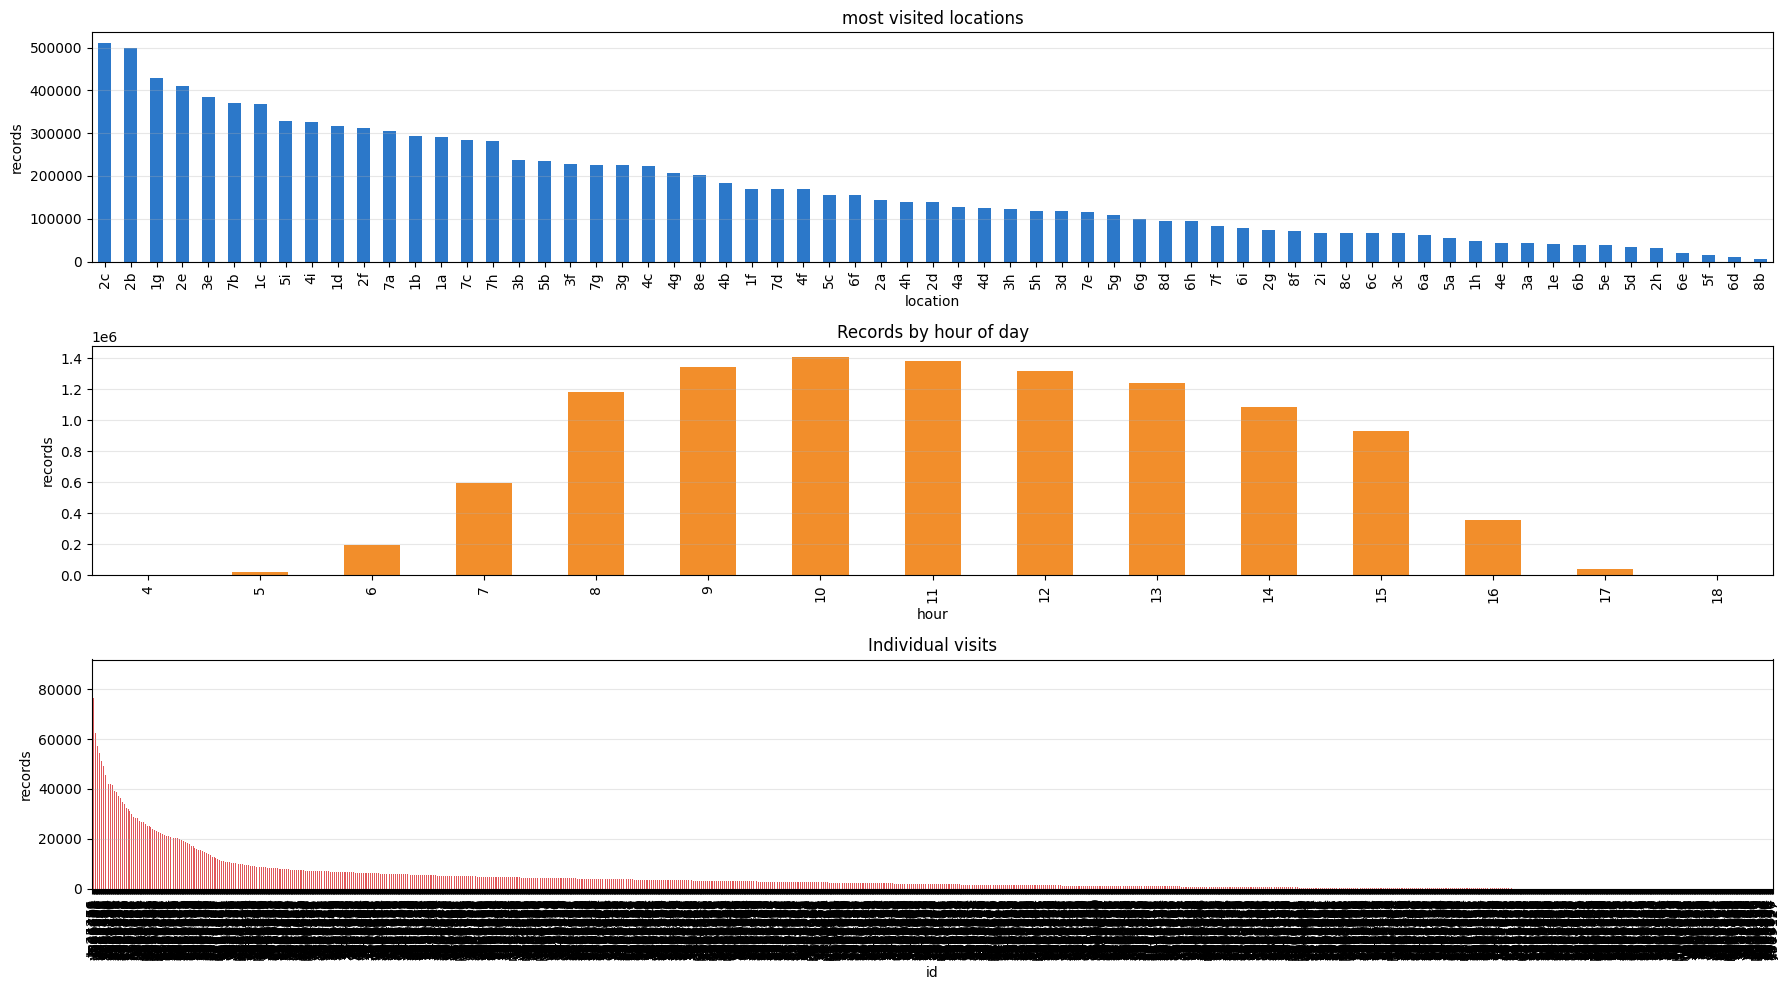

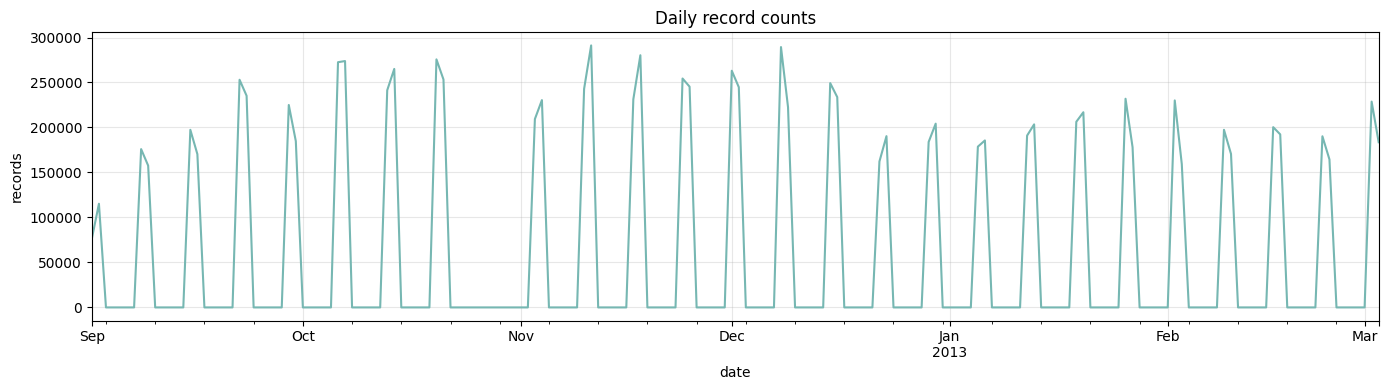

In [123]:
# Summary plots for df

# Convert time to datetime once
if 'time_dt' not in df.columns:
    df['time_dt'] = pd.to_datetime(df['time'], errors='coerce')

# Aggregations
loc_counts = df['location'].value_counts()#.head(20)
ant_counts = df['antenna_number'].value_counts().sort_index()
id_counts = df['id'].value_counts()#.head(50)
hours = df['time_dt'].dropna().dt.hour.value_counts().sort_index()
daily = (
    df.dropna(subset=['time_dt'])
    .groupby(pd.Grouper(key='time_dt', freq='D'))
    .size()
)

# 2x2 summary grid
fig, axes = plt.subplots(3, 1, figsize=(18, 10))

loc_counts.plot(kind='bar', ax=axes[0], color="#2c78c9", title='most visited locations')
axes[0].set_xlabel('location')
axes[0].set_ylabel('records')
axes[0].grid(alpha=0.3, axis='y')

# ant_counts.plot(kind='bar', ax=axes[0, 1], color='#59a14f', title='Antenna number distribution')
# axes[0, 1].set_xlabel('antenna')
# axes[0, 1].set_ylabel('records')
# axes[0, 1].grid(alpha=0.3, axis='y')

hours.plot(kind='bar', ax=axes[1], color='#f28e2b', title='Records by hour of day')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('records')
axes[1].grid(alpha=0.3, axis='y')

id_counts.plot(kind='bar', ax=axes[2], color='#e15759', title='Individual visits')
axes[2].set_xlabel('id')
axes[2].set_ylabel('records')
axes[2].grid(alpha=0.3, axis='y')
# for tick in axes[1, 1].get_xticklabels():
#     tick.set_rotation(90)

plt.tight_layout()

# Daily time series
plt.figure(figsize=(14, 4))
daily.plot(kind='line', color='#76b7b2', title='Daily record counts')
plt.xlabel('date')
plt.ylabel('records')
plt.grid(alpha=0.3)
plt.tight_layout()

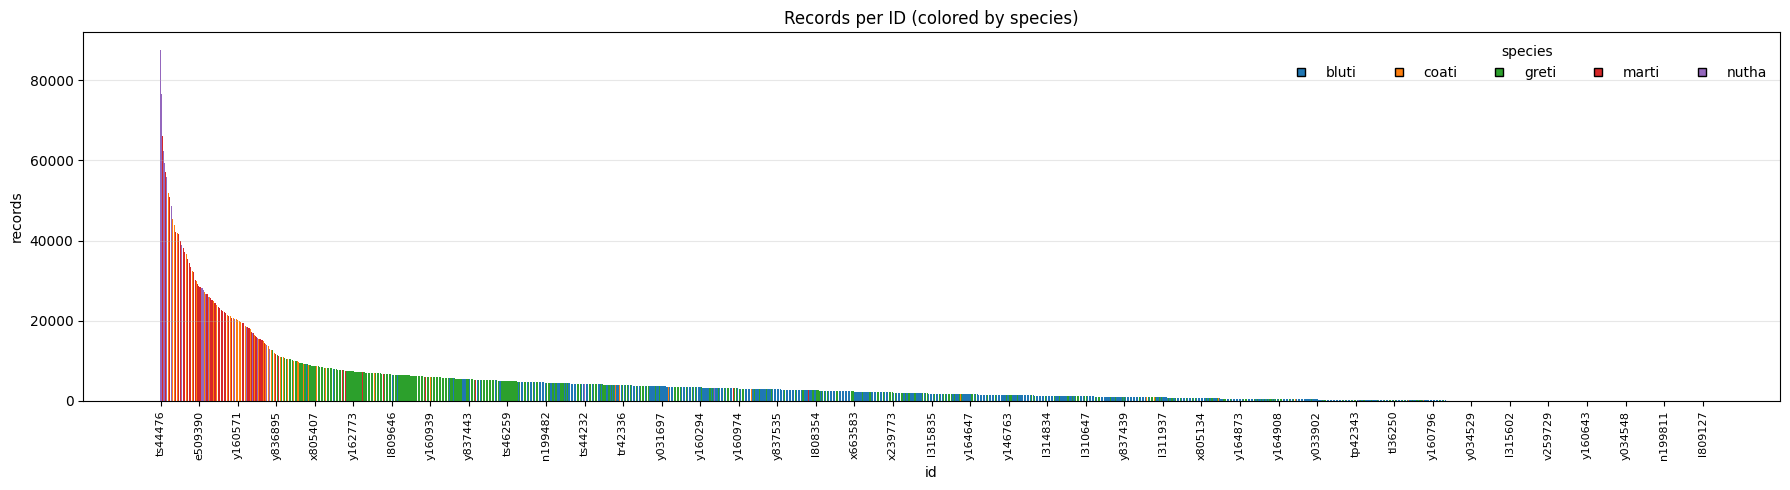

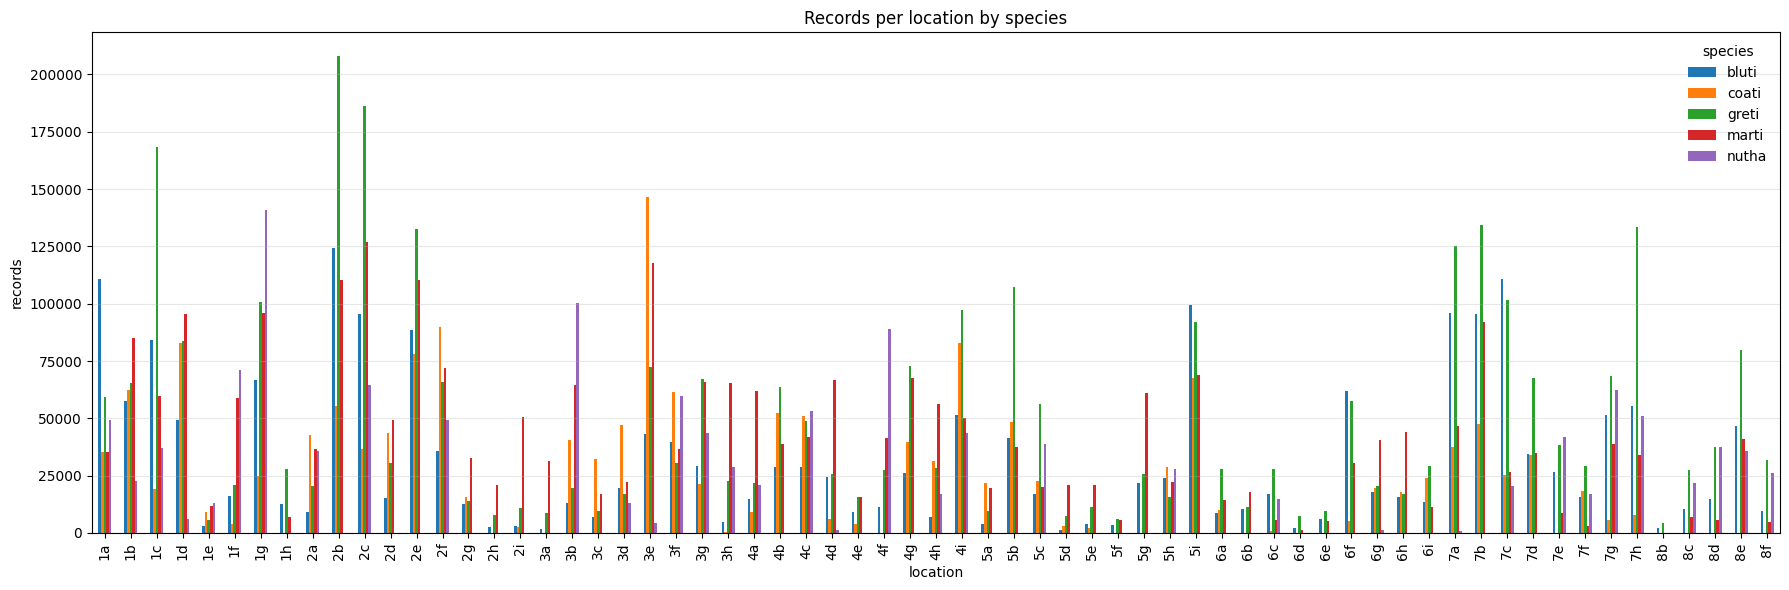

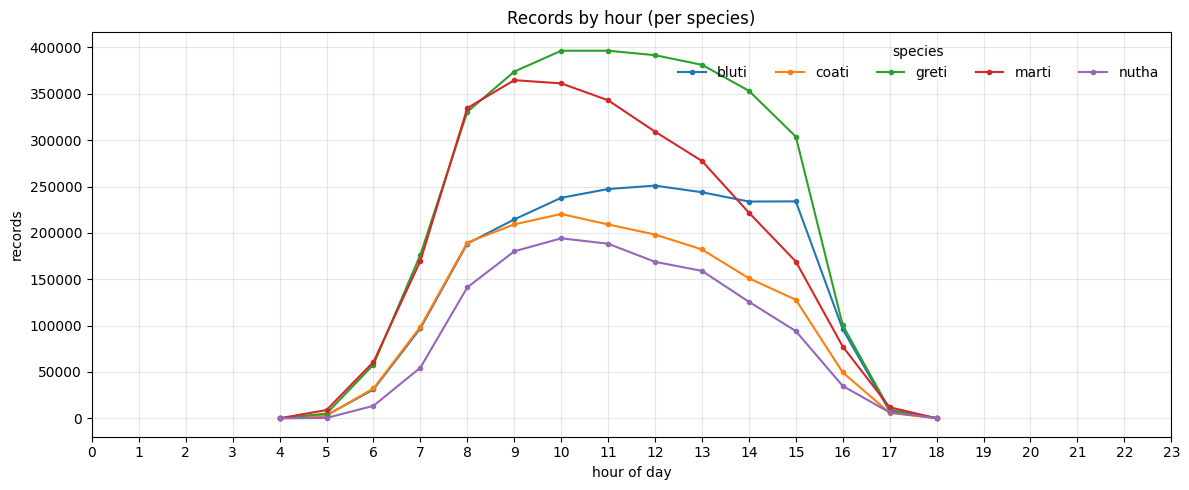

In [124]:
# Ensure species is attached to df
if 'species' not in df.columns:
    df = df.merge(df_ids[['id', 'species']], on='id', how='left')

# Consistent colors per species
species_order = sorted(df['species'].dropna().unique())
cmap = plt.get_cmap('tab10')
species_color = {sp: cmap(i % 10) for i, sp in enumerate(species_order)}

# 1) Records per ID, colored by species
id_counts_df = (
    id_counts.rename('records')
    .reset_index()
    .merge(df_ids[['id', 'species']], on='id', how='left')
)
fig1, ax1 = plt.subplots(figsize=(18, 5))
bar_colors = id_counts_df['species'].map(species_color).fillna('#cccccc')
ax1.bar(id_counts_df['id'], id_counts_df['records'], color=bar_colors, edgecolor='none')
ax1.set_title('Records per ID (colored by species)')
ax1.set_xlabel('id')
ax1.set_ylabel('records')
ax1.grid(alpha=0.3, axis='y')
# Thin x tick labels
if len(id_counts_df) > 40:
    step = max(1, len(id_counts_df) // 40)
    ax1.set_xticks(np.arange(0, len(id_counts_df), step))
    ax1.set_xticklabels(id_counts_df['id'].iloc[::step], rotation=90, fontsize=8)
else:
    ax1.set_xticklabels(id_counts_df['id'], rotation=90, fontsize=8)
handles_spec = [
    plt.Line2D([0], [0], marker='s', linestyle='None',
               markerfacecolor=species_color.get(sp), color='none', label=sp)
    for sp in species_order
]
if handles_spec:
    ax1.legend(handles=handles_spec, title='species', frameon=False, ncol=len(handles_spec))
fig1.tight_layout()

# 2) Records per location with a series for each species
loc_spec = (
    df.groupby(['location', 'species'])
    .size()
    .unstack(fill_value=0)
    .loc[sorted(df['location'].unique())]
)
fig2, ax2 = plt.subplots(figsize=(18, 6))
loc_spec.plot(kind='bar', ax=ax2,
              color=[species_color.get(sp, '#999999') for sp in loc_spec.columns])
ax2.set_title('Records per location by species')
ax2.set_xlabel('location')
ax2.set_ylabel('records')
ax2.grid(alpha=0.3, axis='y')
ax2.legend(title='species', frameon=False)
ax2.tick_params(axis='x', rotation=90)
fig2.tight_layout()

# 3) Records by hour with a series for each species
hour_spec = (
    df.dropna(subset=['time_dt'])
    .assign(hour=df['time_dt'].dt.hour)
    .groupby(['hour', 'species']).size()
    .unstack(fill_value=0)
    .sort_index()
)
fig3, ax3 = plt.subplots(figsize=(12, 5))
for sp in hour_spec.columns:
    ax3.plot(hour_spec.index, hour_spec[sp], marker='o', ms=3,
             label=sp, color=species_color.get(sp, None))
ax3.set_title('Records by hour (per species)')
ax3.set_xlabel('hour of day')
ax3.set_ylabel('records')
ax3.set_xticks(range(0, 24))
ax3.grid(alpha=0.3)
ax3.legend(title='species', frameon=False, ncol=len(hour_spec.columns))
fig3.tight_layout()

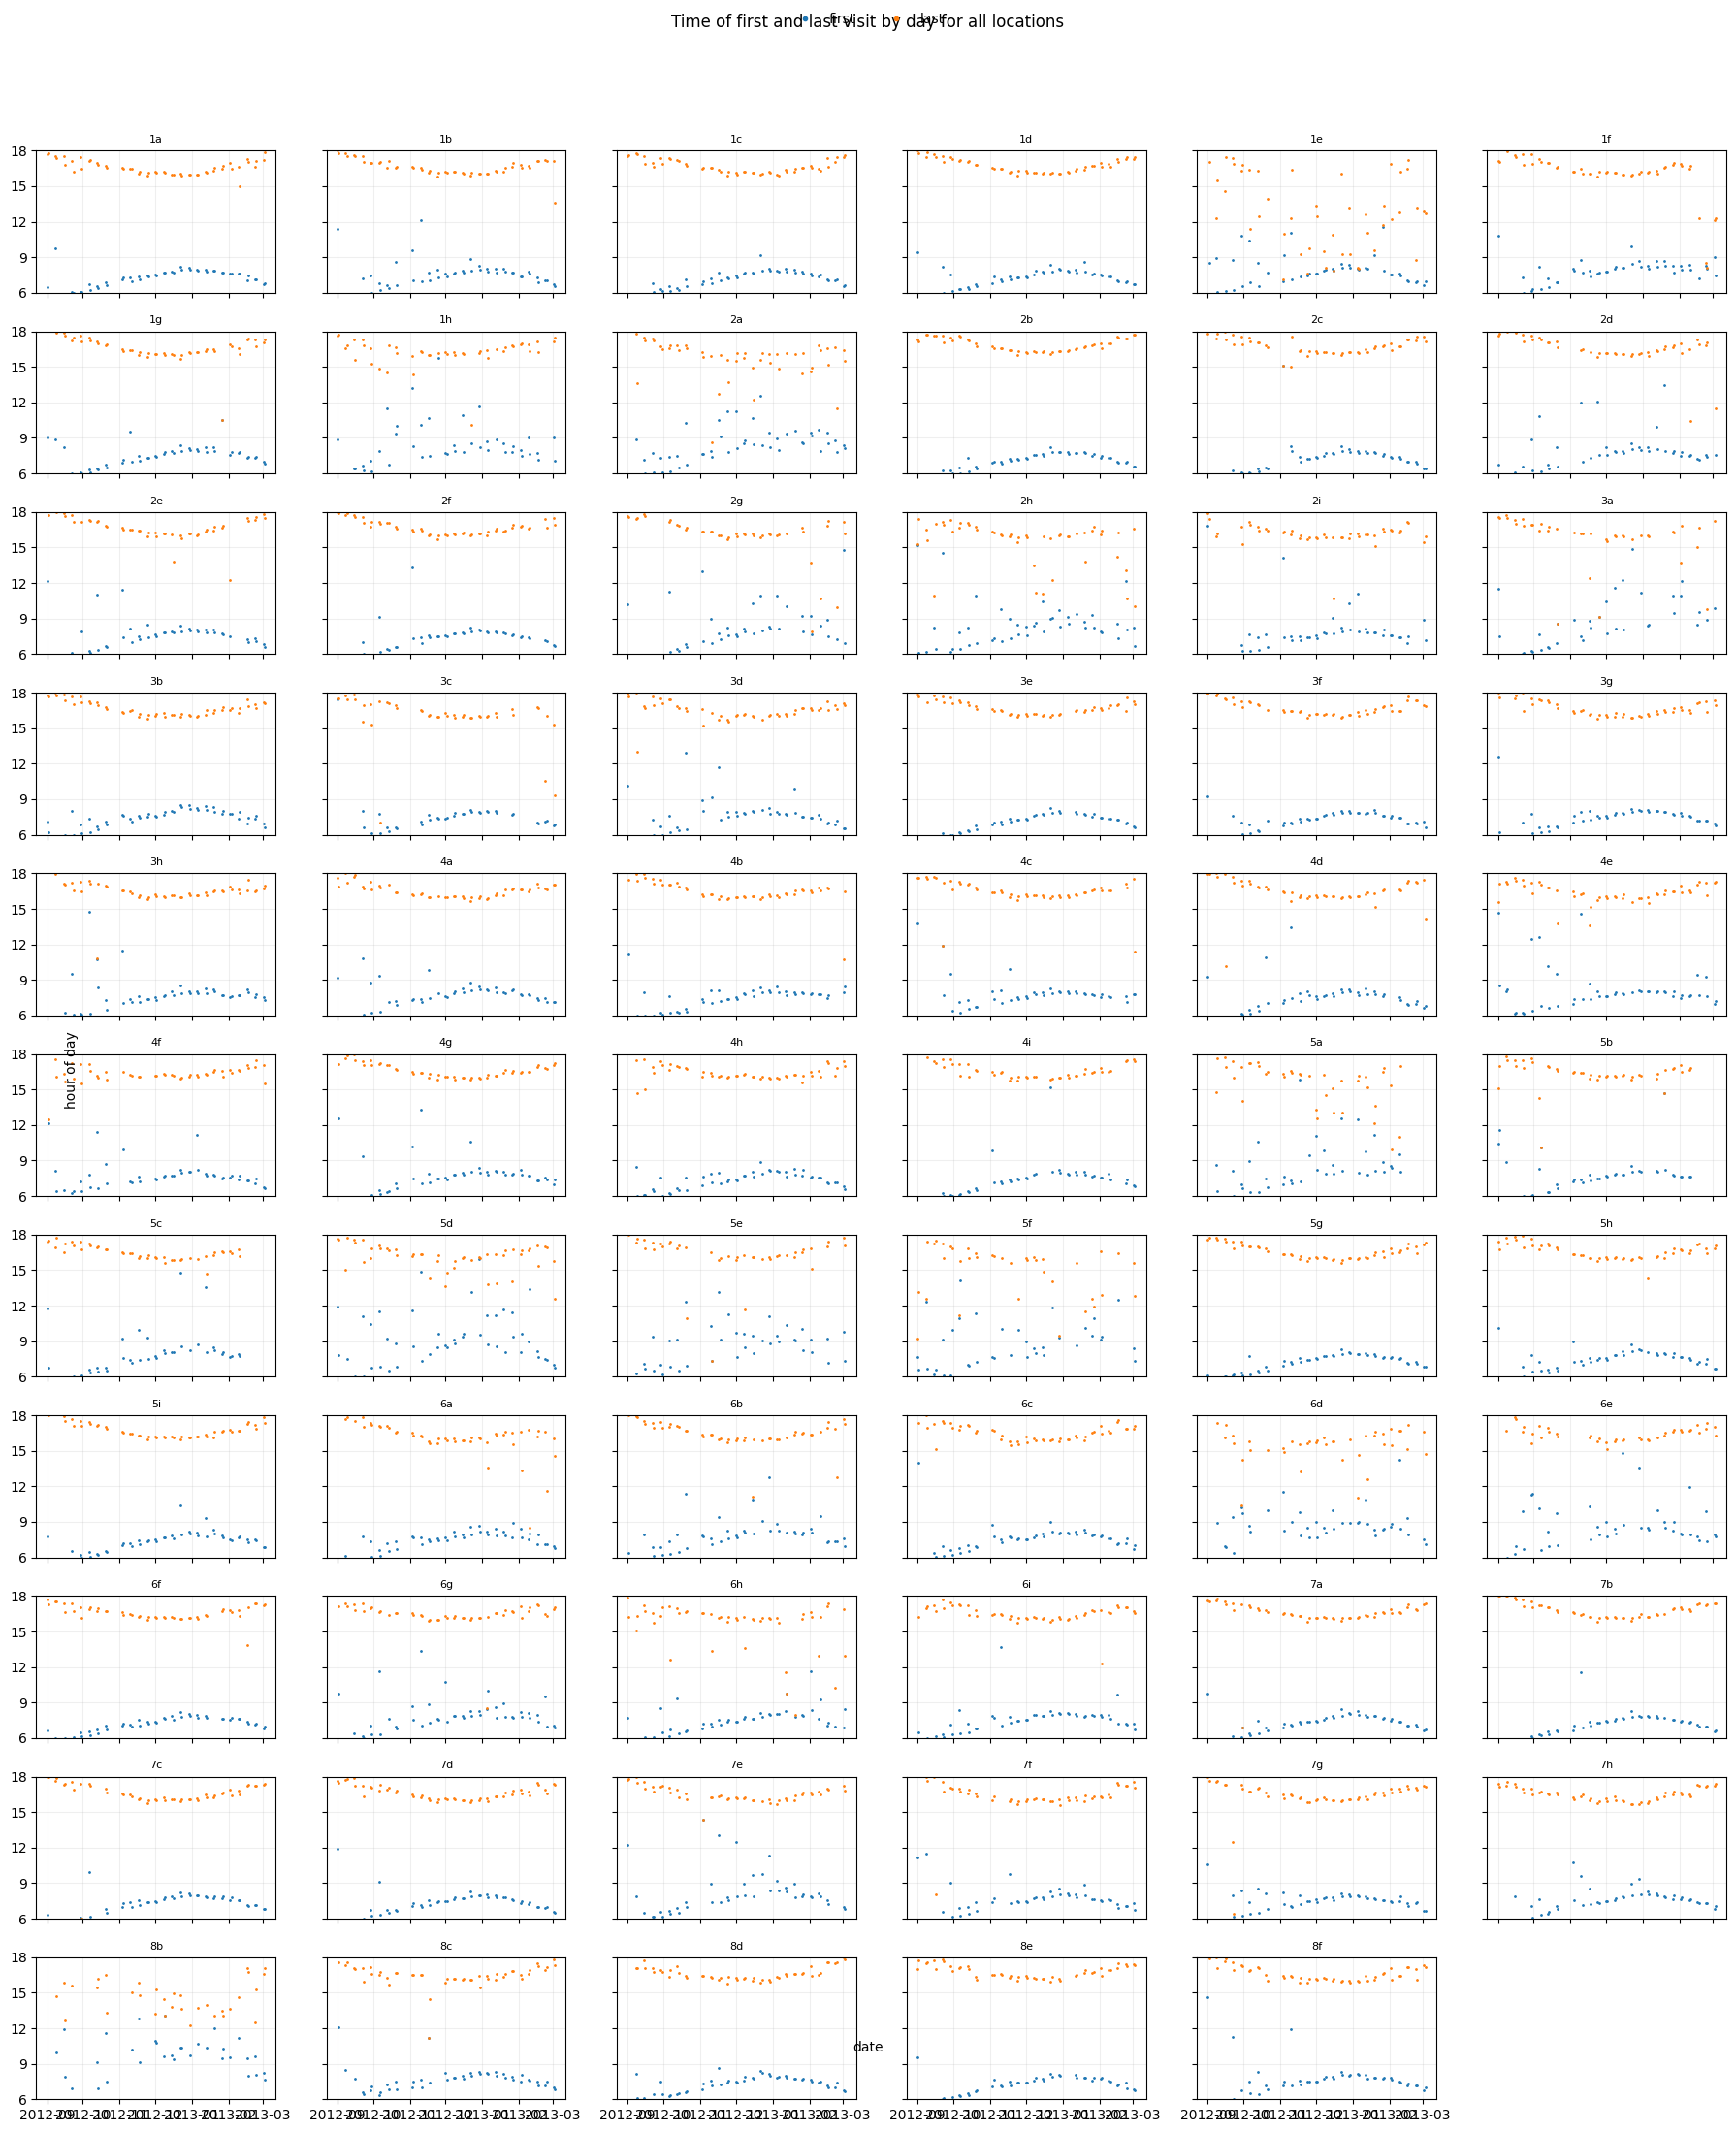

In [125]:
# First/last visit time by day for each location

# Ensure a day column exists
if 'day' not in df.columns:
    df['day'] = df['time_dt'].dt.floor('D')

# Aggregate first and last visit times per location/day
loc_day_times = (
    df.dropna(subset=['time_dt'])
    .groupby(['location', 'day'])['time_dt']
    .agg(first_time='min', last_time='max')
    .reset_index()
)

# Convert to hour-of-day (float) for plotting on y-axis
for col in ('first_time', 'last_time'):
    loc_day_times[f'{col}_hour'] = (
        loc_day_times[col].dt.hour
        + loc_day_times[col].dt.minute / 60
        + loc_day_times[col].dt.second / 3600
    )

# Plot small multiples for all locations
locations = sorted(loc_day_times['location'].unique())
n = len(locations)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig_times, axes_times = plt.subplots(
    nrows, ncols, figsize=(ncols * 3, nrows * 2), sharex=True, sharey=True
)
axs = axes_times.ravel() if isinstance(axes_times, np.ndarray) else [axes_times]

for i, loc in enumerate(locations):
    ax = axs[i]
    sub = loc_day_times[loc_day_times['location'] == loc]
    ax.plot(sub['day'], sub['first_time_hour'], '.', ms=2, color='#1f77b4', label='first')
    ax.plot(sub['day'], sub['last_time_hour'], '.', ms=2, color='#ff7f0e', label='last')
    ax.set_title(loc, fontsize=8)
    ax.grid(alpha=0.2)
    ax.set_ylim(6, 18)
    ax.set_yticks([6,9, 12,15, 18])

# Hide any unused subplots
for j in range(len(locations), len(axs)):
    axs[j].axis('off')

# Shared labels and legend
fig_times.suptitle('Time of first and last visit by day for all locations', y=0.995)
fig_times.text(0.5, 0.04, 'date', ha='center')
fig_times.text(0.04, 0.5, 'hour of day', va='center', rotation='vertical')

handles = [
    plt.Line2D([0], [0], marker='.', linestyle='None', color='#1f77b4', label='first'),
    plt.Line2D([0], [0], marker='.', linestyle='None', color='#ff7f0e', label='last'),
]
fig_times.legend(handles=handles, loc='upper center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0, 1, 0.96))

[[5.00000000e-01 0.00000000e+00 1.00000000e+00 1.00000000e+00]
 [4.68627451e-01 4.92599411e-02 9.99696452e-01 1.00000000e+00]
 [4.37254902e-01 9.84002783e-02 9.98785992e-01 1.00000000e+00]
 [4.05882353e-01 1.47301698e-01 9.97269173e-01 1.00000000e+00]
 [3.74509804e-01 1.95845467e-01 9.95146916e-01 1.00000000e+00]
 [3.43137255e-01 2.43913720e-01 9.92420510e-01 1.00000000e+00]
 [3.11764706e-01 2.91389747e-01 9.89091608e-01 1.00000000e+00]
 [2.80392157e-01 3.38158275e-01 9.85162233e-01 1.00000000e+00]
 [2.49019608e-01 3.84105749e-01 9.80634770e-01 1.00000000e+00]
 [2.17647059e-01 4.29120609e-01 9.75511968e-01 1.00000000e+00]
 [1.86274510e-01 4.73093557e-01 9.69796936e-01 1.00000000e+00]
 [1.54901961e-01 5.15917826e-01 9.63493144e-01 1.00000000e+00]
 [1.23529412e-01 5.57489439e-01 9.56604420e-01 1.00000000e+00]
 [9.21568627e-02 5.97707459e-01 9.49134944e-01 1.00000000e+00]
 [6.07843137e-02 6.36474236e-01 9.41089253e-01 1.00000000e+00]
 [2.94117647e-02 6.73695644e-01 9.32472229e-01 1.000000

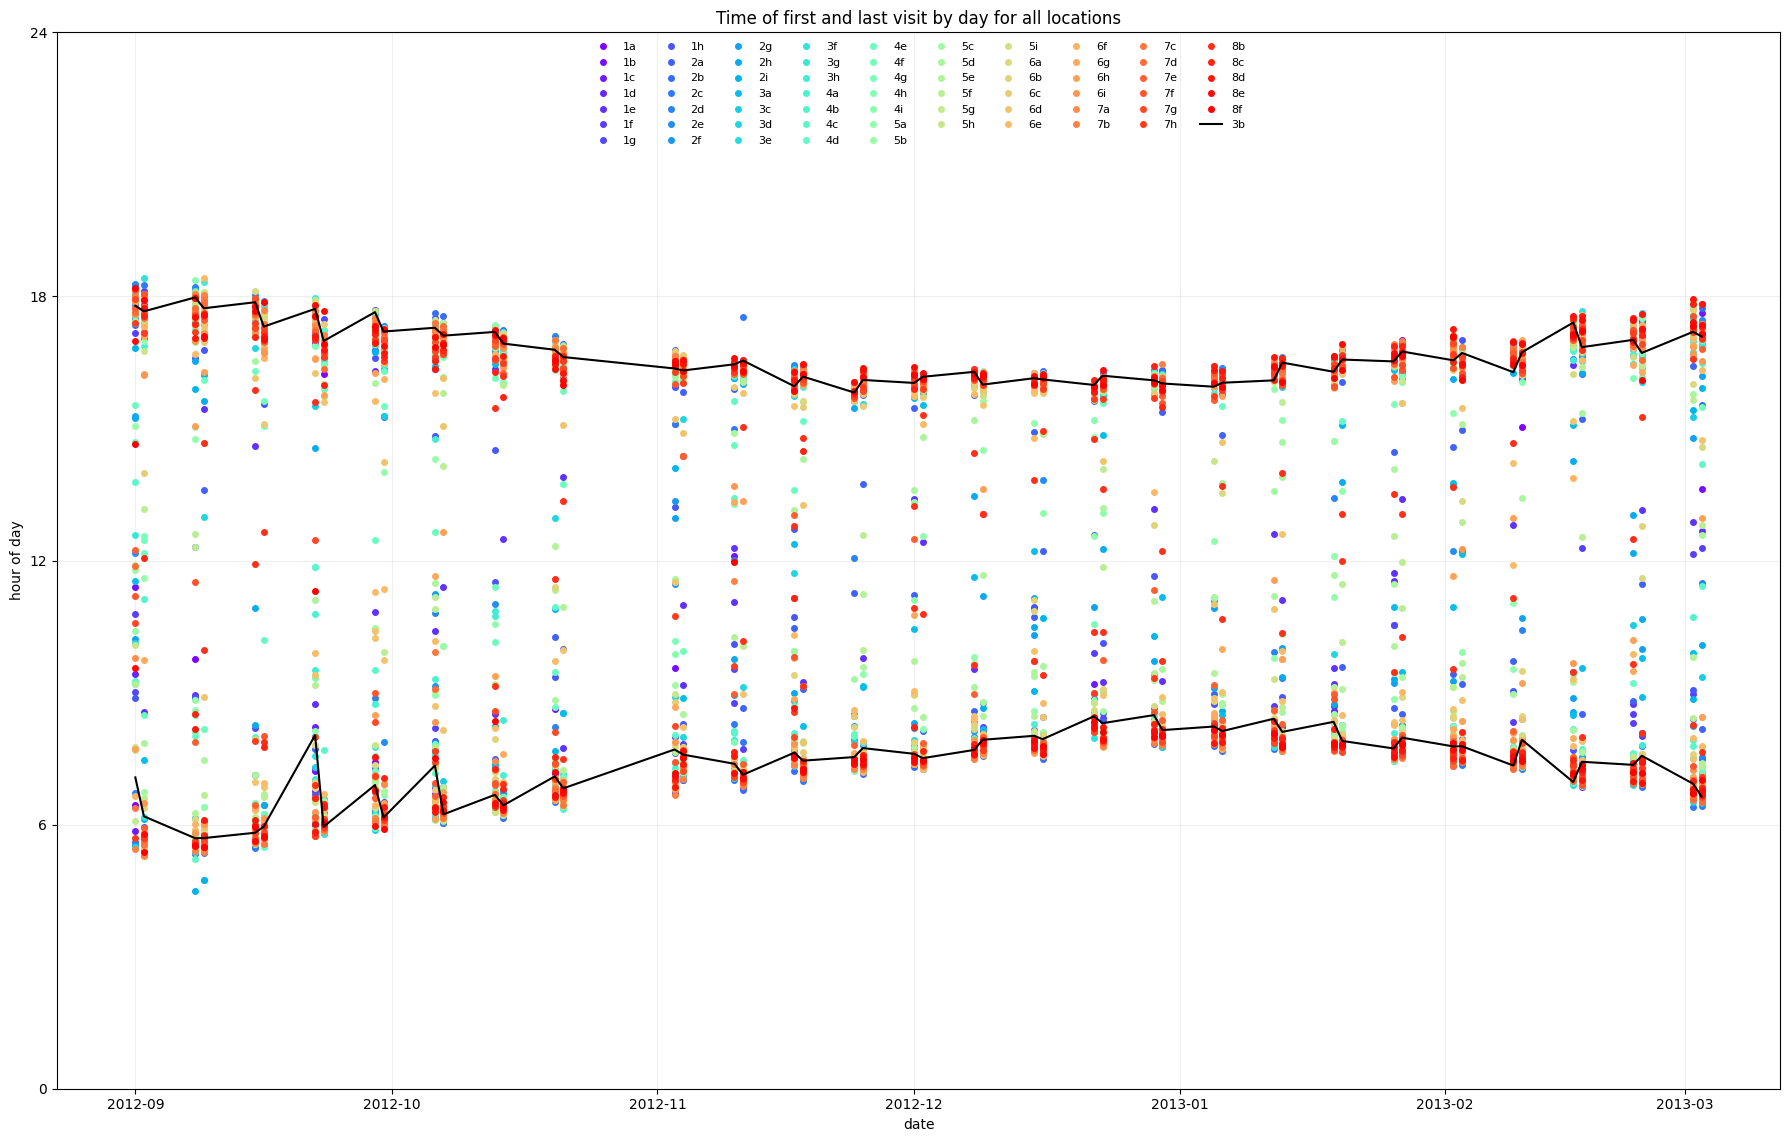

In [126]:
# First/last visit time by day for each location

# Ensure a day column exists
if 'day' not in df.columns:
    df['day'] = df['time_dt'].dt.floor('D')

# Aggregate first and last visit times per location/day
loc_day_times = (
    df.dropna(subset=['time_dt'])
    .groupby(['location', 'day'])['time_dt']
    .agg(first_time='min', last_time='max')
    .reset_index()
)

# Convert to hour-of-day (float) for plotting on y-axis
for col in ('first_time', 'last_time'):
    loc_day_times[f'{col}_hour'] = (
        loc_day_times[col].dt.hour
        + loc_day_times[col].dt.minute / 60
        + loc_day_times[col].dt.second / 3600
    )

# Plot small plots for all locations
locations = sorted(loc_day_times['location'].unique())
n = len(locations)
ncols = 6
nrows = int(np.ceil(n / ncols))


plt.figure(figsize=(18, 12))
colors = cm.rainbow (np.linspace(0, 1, len(locations)))
print(colors)
for i, loc in enumerate(locations):
    sub = loc_day_times[loc_day_times['location'] == loc]
    if loc == '3b':
        pass
    else:
        plt.plot(sub['day'], sub['first_time_hour'], '.', ms=8, label=loc, color = colors[i])
        plt.plot(sub['day'], sub['last_time_hour'], '.', ms=8, color = colors[i])

#plot clear outlier on top in black
loc = '3b'
sub = loc_day_times[loc_day_times['location'] == loc]
plt.plot(sub['day'], sub['first_time_hour'] , ms=8, label=loc, color = 'black')
plt.plot(sub['day'], sub['last_time_hour'], ms=8, color = 'black')

plt.grid(alpha=0.2)
plt.ylim(0, 24)
plt.yticks([0, 6, 12, 18, 24])

plt.title('Time of first and last visit by day for all locations')
plt.xlabel('date')
plt.ylabel('hour of day')
plt.legend(loc='upper center', ncol=10, frameon=False, fontsize=8)
# # Shared labels and legend
# fig_times.suptitle('Time of first and last visit by day for all locations', y=0.995)
# fig_times.text(0.5, 0.04, 'date', ha='center')
# fig_times.text(0.04, 0.5, 'hour of day', va='center', rotation='vertical')

# handles = [
#     plt.Line2D([0], [0], marker='.', linestyle='None', color='#1f77b4', label='first'),
#     plt.Line2D([0], [0], marker='.', linestyle='None', color='#ff7f0e', label='last'),
# ]
# fig_times.legend(handles=handles, loc='upper center', ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0, 1, 0.96))

# convert records to visits

In [127]:
print(df.head())
df.info()

        id location                 time  antenna_number species  \
0  y160116       7b  2012-09-01 05:26:34               2   marti   
1  y160116       7b  2012-09-01 05:26:35               2   marti   
2  l312839       7b  2012-09-01 05:27:05               1   marti   
3  l312839       7b  2012-09-01 05:27:06               1   marti   
4  l312839       7b  2012-09-01 05:27:07               1   marti   

              time_dt        day  
0 2012-09-01 05:26:34 2012-09-01  
1 2012-09-01 05:26:35 2012-09-01  
2 2012-09-01 05:27:05 2012-09-01  
3 2012-09-01 05:27:06 2012-09-01  
4 2012-09-01 05:27:07 2012-09-01  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11111164 entries, 0 to 11111163
Data columns (total 7 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              object        
 1   location        object        
 2   time            object        
 3   antenna_number  int64         
 4   species         object        
 5   time_dt   

In [185]:
df_process = df.dropna(subset=['time_dt']).sort_values(['id', 'time_dt']).copy()
df_process=df_process.reset_index(drop=True)
df_process = df_process[['id', 'location', 'species', 'time_dt']]
df_process = df_process.sort_values(['id', 'time_dt'])


In [188]:
df_process.info()
df_process.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11111164 entries, 0 to 11111163
Data columns (total 4 columns):
 #   Column    Dtype         
---  ------    -----         
 0   id        object        
 1   location  object        
 2   species   object        
 3   time_dt   datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 339.1+ MB


,id,location,species,time_dt
0,c695905,1d,bluti,2012-09-08 06:38:14
1,c695905,1d,bluti,2012-09-08 06:39:14
2,c695905,1d,bluti,2012-09-08 06:41:44
3,c695905,1d,bluti,2012-09-08 06:41:45
4,c695905,1d,bluti,2012-09-08 06:41:46
5,c695905,1d,bluti,2012-09-08 07:04:03
6,c695905,1d,bluti,2012-09-08 07:05:38
7,c695905,1d,bluti,2012-09-08 07:36:48
8,c695905,1d,bluti,2012-09-08 07:39:34
9,c695905,1d,bluti,2012-09-08 07:39:35


In [189]:
# if the time between subsequent records is more than 2 minute apart,
# we consider this a departure and a new arrival, remove all records which are not arrivals or departures
df_process['time_diff'] = df_process.groupby('id')['time_dt'].diff().dt.total_seconds().fillna(0)
df_process['is_new_visit'] = df_process['time_diff'] > 180  # more than 2 minute apart
df_process['is_arrival'] = df_process['is_new_visit'] | (df_process.groupby('id').cumcount() == 0)
df_process['is_departure'] = df_process['is_new_visit'].shift(-1, fill_value=True) | (df_process.groupby('id').cumcount(ascending=False) == 0)
df_ariv_depart = df_process[df_process['is_arrival'] | df_process['is_departure']].copy()
df_ariv_depart = df_ariv_depart.drop(columns=['time_diff', 'is_new_visit', 'is_arrival', 'is_departure'])
df_ariv_depart = df_ariv_depart.reset_index(drop=True)


In [192]:
print(df_ariv_depart.info())
print(f'preprocess - {len(df_process)} records, arrivals/departures - {len(df_ariv_depart)} records. reduction of {len(df_process)-len(df_ariv_depart)} records')
df_ariv_depart.head(30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2194350 entries, 0 to 2194349
Data columns (total 4 columns):
 #   Column    Dtype         
---  ------    -----         
 0   id        object        
 1   location  object        
 2   species   object        
 3   time_dt   datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 67.0+ MB
None
preprocess - 11111164 records, arrivals/departures - 2194350 records. reduction of 8916814 records


,id,location,species,time_dt
0,c695905,1d,bluti,2012-09-08 06:38:14
1,c695905,1d,bluti,2012-09-08 06:41:46
2,c695905,1d,bluti,2012-09-08 07:04:03
3,c695905,1d,bluti,2012-09-08 07:05:38
4,c695905,1d,bluti,2012-09-08 07:36:48
5,c695905,1d,bluti,2012-09-08 07:39:37
6,c695905,1d,bluti,2012-09-08 08:34:49
7,c695905,1d,bluti,2012-09-08 09:28:02
8,c695905,1d,bluti,2012-09-08 09:28:03
9,c695905,1d,bluti,2012-09-08 09:51:06


# individual bird path

In [147]:
bird_id = id_counts_df['id'][0]
print(bird_id)

ts44476


In [148]:
df_locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    66 non-null     object 
 1   x       66 non-null     float64
 2   y       66 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.7+ KB


In [75]:
print(df_locations.head())

  Name          x          y
0   1A  447023.36  208492.29
1   1B  446603.09  208760.79
2   1C  446638.11  209065.99
3   1D  446419.64  209234.44
4   1E  446394.62  208922.57


In [164]:
# Lookup table for distances between locations
D = pd.DataFrame(
    cdist(df_locations[['x','y']], df_locations[['x','y']], metric='euclidean'),
    index=df_locations['Name'], columns=df_locations['Name']
)
# example lookup:
d_ij = D.loc['1A','1E']  # metres, should be 761.8758862176879 for 1A to 1E
print(d_ij)

761.8758862176879


In [152]:
print(D.loc['1A','1A'])

0.0


In [193]:
# distance to the next row's location (per id)
df_ariv_depart['next_location'] = df_ariv_depart.groupby('id')['location'].shift(-1)
df_ariv_depart['next_time'] = df_ariv_depart.groupby('id')['time_dt'].shift(-1)
df_ariv_depart['dt'] = (df_ariv_depart['next_time'] - df_ariv_depart['time_dt']).dt.total_seconds()
# drop rows where next_location is NaN (last record per id)
df_ariv_depart = df_ariv_depart.dropna().reset_index(drop=True)
# distance between current and next location
df_ariv_depart['distance'] = df_ariv_depart.apply(
    lambda row: D.loc[row['location'].upper(), row['next_location'].upper()], axis=1
)
df_ariv_depart['speed_m_s'] = df_ariv_depart['distance'] / df_ariv_depart['dt']

In [198]:
df_visit = df_ariv_depart.sort_values(['id','time_dt'])
df_visit.head(30)


,id,location,species,time_dt,next_location,next_time,dt,distance,speed_m_s
0,c695905,1d,bluti,2012-09-08 06:38:14,1d,2012-09-08 06:41:46,212.0,0.000000,0.000000
1,c695905,1d,bluti,2012-09-08 06:41:46,1d,2012-09-08 07:04:03,1337.0,0.000000,0.000000
2,c695905,1d,bluti,2012-09-08 07:04:03,1d,2012-09-08 07:05:38,95.0,0.000000,0.000000
3,c695905,1d,bluti,2012-09-08 07:05:38,1d,2012-09-08 07:36:48,1870.0,0.000000,0.000000
4,c695905,1d,bluti,2012-09-08 07:36:48,1d,2012-09-08 07:39:37,169.0,0.000000,0.000000
5,c695905,1d,bluti,2012-09-08 07:39:37,1d,2012-09-08 08:34:49,3312.0,0.000000,0.000000
6,c695905,1d,bluti,2012-09-08 08:34:49,1d,2012-09-08 09:28:02,3193.0,0.000000,0.000000
7,c695905,1d,bluti,2012-09-08 09:28:02,1d,2012-09-08 09:28:03,1.0,0.000000,0.000000
8,c695905,1d,bluti,2012-09-08 09:28:03,1d,2012-09-08 09:51:06,1383.0,0.000000,0.000000
9,c695905,1d,bluti,2012-09-08 09:51:06,1d,2012-09-08 09:53:23,137.0,0.000000,0.000000


In [200]:
df_bird_speed = df_visit[df_visit['id'] == bird_id].copy()
df_bird_speed.head(20)

,id,location,species,time_dt,next_location,next_time,dt,distance,speed_m_s
825457,ts44476,1f,nutha,2012-09-02 06:48:36,1f,2012-09-02 06:51:20,164.0,0.0,0.0
825458,ts44476,1f,nutha,2012-09-02 06:51:20,1f,2012-09-02 06:57:48,388.0,0.0,0.0
825459,ts44476,1f,nutha,2012-09-02 06:57:48,1f,2012-09-02 06:57:58,10.0,0.0,0.0
825460,ts44476,1f,nutha,2012-09-02 06:57:58,1f,2012-09-02 07:01:15,197.0,0.0,0.0
825461,ts44476,1f,nutha,2012-09-02 07:01:15,1f,2012-09-02 07:07:28,373.0,0.0,0.0
825462,ts44476,1f,nutha,2012-09-02 07:07:28,1f,2012-09-02 07:10:29,181.0,0.0,0.0
825463,ts44476,1f,nutha,2012-09-02 07:10:29,1f,2012-09-02 07:14:43,254.0,0.0,0.0
825464,ts44476,1f,nutha,2012-09-02 07:14:43,1f,2012-09-02 07:25:06,623.0,0.0,0.0
825465,ts44476,1f,nutha,2012-09-02 07:25:06,1f,2012-09-02 07:32:15,429.0,0.0,0.0
825466,ts44476,1f,nutha,2012-09-02 07:32:15,1f,2012-09-02 08:01:48,1773.0,0.0,0.0


Text(0.5, 1.0, 'log(speed m/s) over time for ts44476')

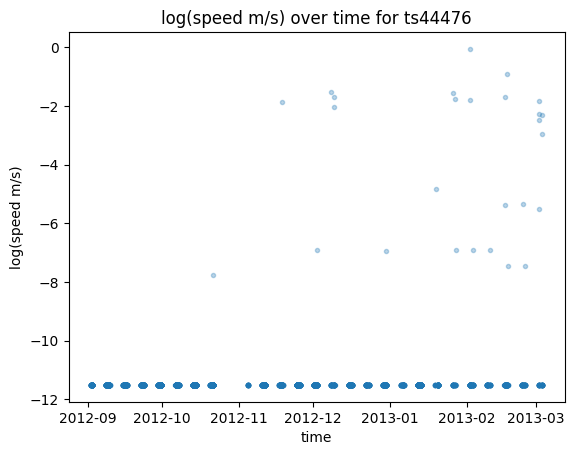

In [213]:
plt.plot(df_bird_speed['time_dt'], np.log(df_bird_speed['speed_m_s']+0.00001), '.', alpha=0.3)
plt.xlabel('time')
plt.ylabel('log(speed m/s)')
plt.title(f'log(speed m/s) over time for {bird_id}')

Text(0.5, 1.0, 'log(speed m/s) over time for all birds')

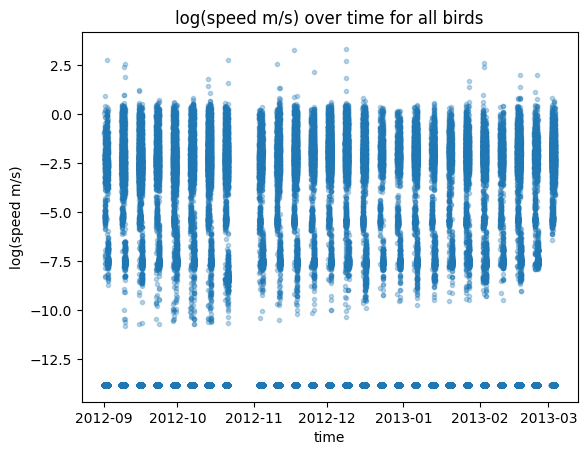

In [212]:
plt.plot(df_visit['time_dt'], np.log(df_visit['speed_m_s']+0.000001), '.', alpha=0.3)
plt.xlabel('time')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over time for all birds')

Text(0.5, 1.0, 'log(speed m/s) over distance for all birds')

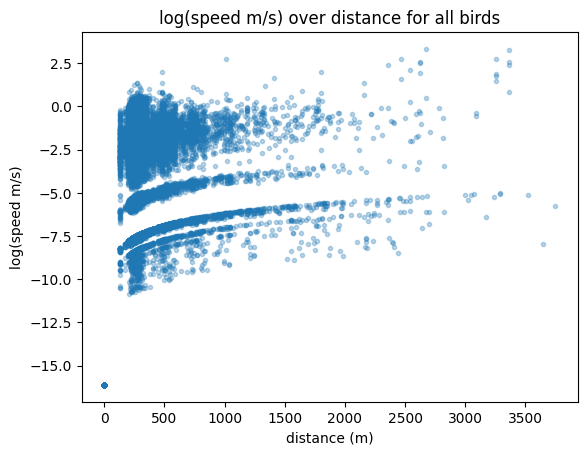

In [211]:
plt.plot(df_visit['distance'], np.log(df_visit['speed_m_s']+0.0000001), '.', alpha=0.3)
plt.xlabel('distance (m)')
plt.ylabel('log(speed m/s)')
plt.title('log(speed m/s) over distance for all birds')

In [216]:
df_visit.head()

,id,location,species,time_dt,next_location,next_time,dt,distance,speed_m_s
0,c695905,1d,bluti,2012-09-08 06:38:14,1d,2012-09-08 06:41:46,212.0,0.0,0.0
1,c695905,1d,bluti,2012-09-08 06:41:46,1d,2012-09-08 07:04:03,1337.0,0.0,0.0
2,c695905,1d,bluti,2012-09-08 07:04:03,1d,2012-09-08 07:05:38,95.0,0.0,0.0
3,c695905,1d,bluti,2012-09-08 07:05:38,1d,2012-09-08 07:36:48,1870.0,0.0,0.0
4,c695905,1d,bluti,2012-09-08 07:36:48,1d,2012-09-08 07:39:37,169.0,0.0,0.0


In [219]:
# max speed should be around 20km/h as max is roughly 50km/h and they wont go in a straigfht lineas fast as possible one location to next
print(f'50km/h in m/s is {50*1000/3600}')

50km/h in m/s is 13.88888888888889


In [218]:
max_speed_species = df_visit.groupby('species')['speed_m_s'].max().sort_values(ascending=False)
print(max_speed_species.head(20))

species
greti    27.832975
bluti    26.457229
marti    12.735634
coati     5.298833
nutha     2.482974
Name: speed_m_s, dtype: float64


In [217]:
# max speed attained by each bird
max_speeds = df_visit.groupby('id')['speed_m_s'].max().sort_values(ascending=False)
print(max_speeds.head(20)) 

id
l315425    27.832975
y031516    26.457229
x805375    15.931096
y160983    15.830099
y034278    15.294994
y160401    12.735634
y031509    12.599765
l808404    11.297510
ts46416     8.364716
y162787     7.280693
y146213     7.200512
y031559     5.298833
ts44716     3.895261
v260964     3.888339
l315131     3.780330
y035978     3.437355
y031564     3.307487
y160998     3.154254
l312151     2.919706
y161516     2.717026
Name: speed_m_s, dtype: float64
